In [176]:
import os
os.chdir('/Users/home/scopesim')
import numpy as np
from astropy.io import fits
from astropy import units as u
from matplotlib import pyplot as plt

## Setting up scopesim and instrument packages

In [178]:
import scopesim as sim

In [179]:
#sim.download_packages(["ELT", "Armazones", "METIS"])

In [180]:
sim.bug_report()

Python:
3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:54:21) [Clang 16.0.6 ]

Installed Python packages:
           anisocado: 0.4.0
         astar-utils: 0.4.0
             astropy: 6.1.7
      beautifulsoup4: 4.13.5
            docutils: 0.19
               httpx: 0.28.1
                lxml: 5.4.0
          matplotlib: 3.10.6
      more-itertools: 10.3.0
               numpy: 1.26.4
           packaging: 25.0
               pooch: 1.8.2
              pyyaml: 6.0.2
               scipy: 1.16.2
            scopesim: 0.11.0
       scopesim_data: could not be loaded.
  scopesim_templates: 0.6.1
         skycalc-ipy: 0.6.0
             synphot: 1.5.0
                tqdm: 4.67.1

Installed IRDB packages:
      METIS: 2025-09-22
  Armazones: 2023-07-11
        ELT: 2025-06-30

Operating System info:
   System: Darwin
  Release: 24.6.0
  Version: Darwin Kernel Version 24.6.0: Mon Jul 14 11:30:40 PDT 2025; root:xnu-11417.140.69~1/RELEASE_ARM64_T6041
  Machine: arm64


## Sky and object simulations

In [182]:
exptime = 3600# * u.s
cmd = sim.UserCommands(use_instrument="METIS", set_modes=["lss_l"], properties={"!OBS.exptime": exptime, "!OBS.dit": None, "!OBS.ndit": None})

In [183]:
#exptime = 3600

In [184]:
metis = sim.OpticalTrain(cmd)

In [185]:
metis.observe()      # blank sky

astar.scopesim.optics.optical_train - Observing empty field


 FOV effects:   0%|          | 0/2 [00:00<?, ?it/s]

astar.scopesim.effects.psfs - Interpolating PSF onto (2600, 15, 1024) cube


 PSF slices:   0%|          | 0/2600 [00:00<?, ?it/s]

astar.scopesim.optics.image_plane - No BUNIT found in added HDU.


astar.scopesim.effects.electronic - Detector mode set to slow
astar.scopesim.effects.electronic - Requested exposure time: 3600.000 s
astar.scopesim.effects.electronic - Required DIT without saturation: 4.324 s
astar.scopesim.effects.electronic - Exposure parameters: DIT = 4.322 s, NDIT = 833
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.electronic - Applying gain 2.5
astar.scopesim.effects.electronic - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 4.322 s, NDIT = 833
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s


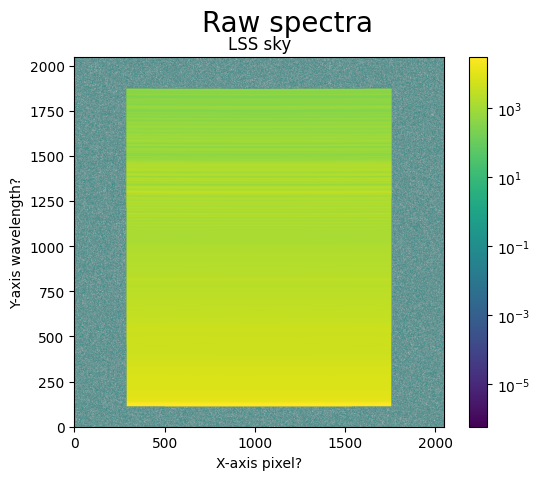

In [186]:
bgresult = metis.readout(detector_readout_mode="auto", dit=None, ndit=None)[0] 
bgresult[1].data #<<= u.electron  # Apply unit     
imskyraw=plt.imshow(bgresult[1].data, origin="lower", norm="log")#no .value any more
plt.xlabel("X-axis pixel?")
plt.ylabel("Y-axis wavelength?")
plt.title('LSS sky')
plt.suptitle("Raw spectra", fontsize=20);
plt.colorbar(imskyraw)

In [187]:
sky_implane = metis.image_planes[0].data
sky_readout = metis.readout(exptime=exptime)[0]

astar.scopesim.effects.electronic - Requested exposure time: 3600.000 s
astar.scopesim.effects.electronic - Required DIT without saturation: 4.324 s
astar.scopesim.effects.electronic - Exposure parameters: DIT = 4.322 s, NDIT = 833
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.electronic - Applying gain 2.5
astar.scopesim.effects.electronic - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 4.322 s, NDIT = 833
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s


In [188]:
# Save dit and ndit for later!
dit, ndit = metis.cmds["!OBS.dit"], metis.cmds["!OBS.ndit"]
print(dit, ndit)

4.321728691476591 833


In [189]:
#with fits.open("AGN_sim_preparedCircinus.fits") as hdul:
with fits.open("circinus_ready_for_scopesim.fits") as hdul:
    src = sim.Source(cube=hdul)

In [190]:
metis.observe(src)

astar.scopesim.optics.image_plane_utils - WARNING: imagehdu.data.ndim is 3, but wcs.naxis with key   is 2, both should be equal.
astar.scopesim.optics.image_plane_utils - WARNING: Non-linear WCS rescaled using linear procedure.


 FOV effects:   0%|          | 0/2 [00:00<?, ?it/s]

astar.scopesim.optics.image_plane - No BUNIT found in added HDU.


In [191]:
src_implane = metis.image_planes[0].data

In [192]:
src_readout  = metis.readout(dit=dit, ndit=ndit)[0]

astar.scopesim.effects.electronic - Exposure parameters: DIT = 4.322 s, NDIT = 833
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.electronic - Applying gain 2.5
astar.scopesim.effects.electronic - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 4.322 s, NDIT = 833
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s


(2048, 2048)


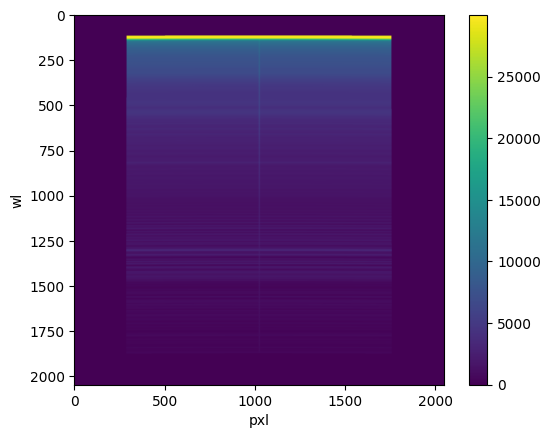

In [193]:
imsrcraw=plt.imshow(src_readout[1].data)
plt.colorbar(imsrcraw)
plt.xlabel('pxl')
plt.ylabel('wl')
print(src_readout[1].data.shape)


In [194]:
bgsub = src_readout[1].data - sky_readout[1].data

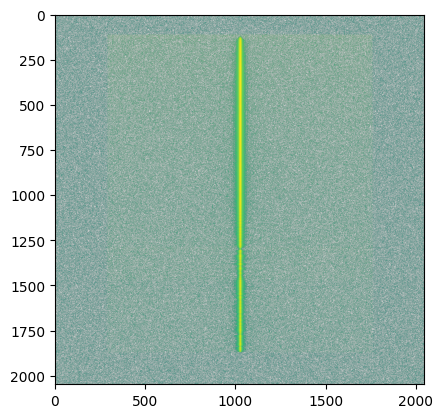

In [195]:
plt.imshow(bgsub, norm='log')

Text(0, 0.5, 'wl')

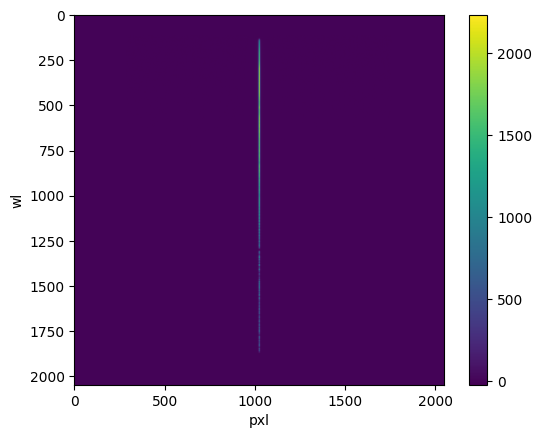

In [196]:
imbgsub=plt.imshow(bgsub)#, norm='log')
plt.colorbar(imbgsub)
plt.xlabel('pxl')
plt.ylabel('wl')



In [197]:
#np.arange(naxis1)

## Estimating SNR from the data
The signal is the spectrum of the target on the background-subtracted readout, `bgsub`. The noise can be estimated from those parts of the readout image that are covered by the slit but are away from the target. I'll use columns 400 to 700 to do this - it could be extended using regions to the right of the target, but that requires a little numpy gymnastics. I'll also do this rowwise to take variations due to atmospheric emission lines and the thermal continuum into account. This is not quite correct as there is (probably) a small tilt of the sky lines with respect to the detector rows, but that should be a minor effect. 

In [199]:
noise = bgsub[:, 400:700].std(axis=1) #one std per row → shape (2048,)
noise2 = bgsub[115:1800, 400:700].std(axis=1) #one std per row in the cropped region → shape (1685,)
sig2=bgsub[115:1800, 1000:1100] #wl,pxl

(2048, 2048) (1, 2048)
(1685, 100) (1, 1685)
(1685,) [ 0.6705469  -0.44371092  0.5214844  ... 33.40363    41.695446
 47.816544  ]


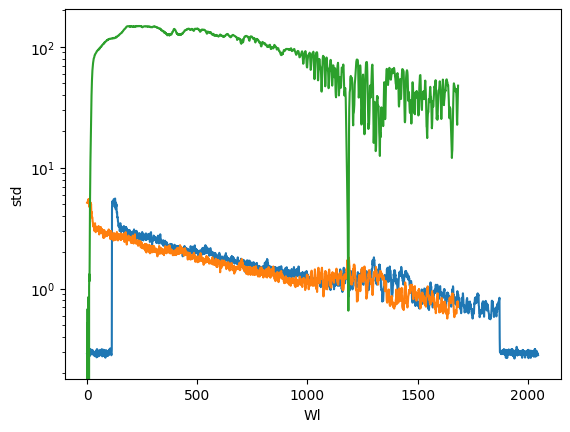

In [200]:
print(bgsub.shape, noise[None, :].shape) #( wl, pxl)  # adds a new row axis → (1, 2048) 2048 is wl
print(sig2.shape, noise2[None,:].shape  ) #( wl, pxl)  # adds a new row axis → (1, 1685) 1685 is wl
fig, ax = plt.subplots()
plt.plot(np.arange(2048), noise)
plt.plot(np.arange(1685), noise2)
plt.plot(np.arange(1685), sig2.mean(axis=1))
ax.set_yscale('log')
plt.xlabel('Wl')
plt.ylabel('std')
print(sig2.mean(axis=1).shape,sig2.mean(axis=1))

Text(0, 0.5, 'wl')

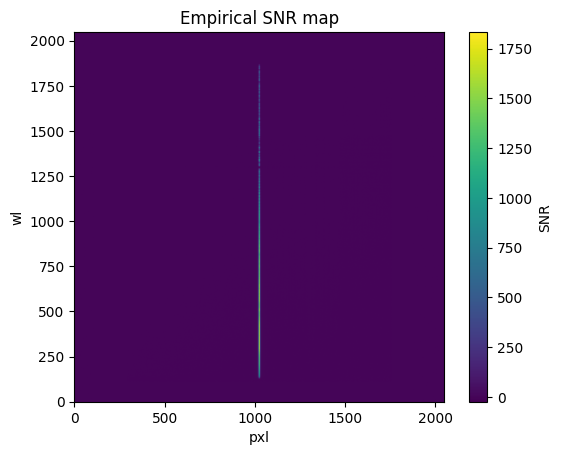

In [224]:
snr_emp = bgsub / noise[None, :]     # empirical SNR  ;  noise[None, :]← aligns to last dimension
snr_empb = bgsub / noise[:, None]     # empirical SNR  ;  noise[None, :]← aligns to first dimension
snr_emp2 = sig2/ noise2[:, None]    # /(1, 1685) 
plt.imshow(snr_emp, origin='lower')

#plt.imshow(snr_empb, origin='lower')
#plt.imshow(snr_emp2, origin='lower')

#plt.imshow(snr_empb[250:1750,990:1100], origin='lower')
plt.title("Empirical SNR map")
plt.colorbar(label="SNR")
plt.xlabel('pxl')
plt.ylabel('wl')

This strikes me as rather high SNR...

## Expected SNR 

In [107]:
bgsub_implane = src_implane - sky_implane

Estimate the noise from the background image. The total number of electrons collected is `dit * ndit * imageplane`, the expected noise is the square root of that (applying Poisson statistics). If we only consider photon noise, we can work with that as all the scalings to reproduce the readout (dividing by `ndit`, dividing by `gain`) apply to both the signal and the noise images. (right?)

In [110]:
snr_exp = dit * ndit * bgsub_implane / np.sqrt(dit * ndit * sky_implane)

Text(0, 0.5, 'wl')

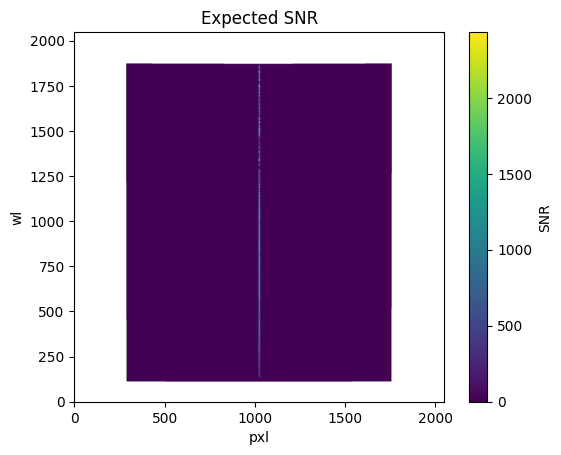

In [112]:
plt.imshow(snr_exp, origin='lower')
plt.colorbar(label="SNR")
plt.title("Expected SNR");
plt.xlabel('pxl')
plt.ylabel('wl')


The SNRs are not terribly far off. I'm surprised that the expected SNR (which is optimistic because readout noise has not been taken into account) is actually lower than the SNR estimated from the data.

## Sanity checks
Let's have a closer look at the noise. The first plot shows the detector readouts with and without the source, as well as the image planes scaled to match the readout (i.e. multiplied by a dit and divided by the gain to get ADU). It will be apparent that there is quite a bit of structure in the background due to the fact that a detector row does not correspond to a single wavelength but cuts through the sky spectrum.

(7500.0, 7600.0)

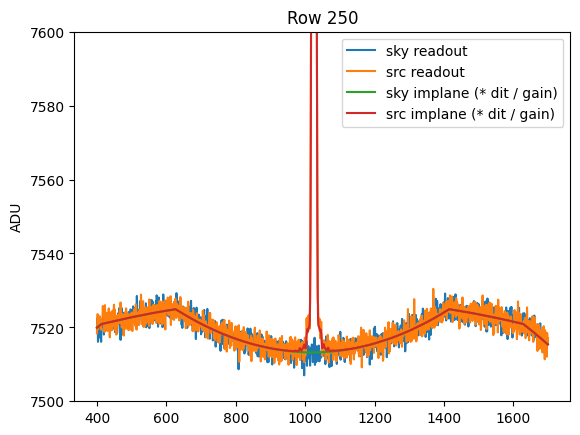

In [116]:
#sig2=bgsub[115:1800, 1000:1100]#wl,pxl
x = np.arange(400, 1700)#pxls
row = 250 #fixing one wl
plt.plot(x, sky_readout[1].data[row,400:1700], label="sky readout")
plt.plot(x, src_readout[1].data[row, 400:1700], label="src readout")
plt.plot(x, sky_implane[row, 400:1700] * dit / 2.5, label="sky implane (* dit / gain)")
plt.plot(x, src_implane[row, 400:1700] * dit / 2.5, label="src implane (* dit / gain)")
plt.ylabel("ADU")
plt.legend()
plt.title(f"Row {row}")
plt.ylim(7500, 7600)

We repeat this plot but this time we scale it to the total number of electrons collected over the exposure time; this is where we can apply Poisson statistics directly. This means that the readouts have to be multiplied by `ndit` and multiplied by the gain (to convert from ADU to electrons). Ignoring the structure in the background, we take the square root of the median of the background as an estimate of the noise. The noise is at least in the right ball park.

In [119]:
med = np.median(sky_implane[row, 400:1700] * dit * ndit)
rms = np.sqrt(med)

(15600000.0, 15700000.0)

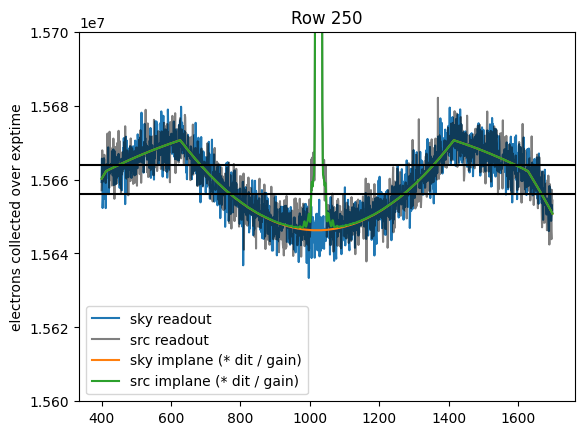

In [121]:
x = np.arange(400, 1700) #pxls
row = 250 #fixing one wl
plt.plot(x, sky_readout[1].data[row,400:1700] * ndit * 2.5, label="sky readout")
plt.plot(x, src_readout[1].data[row, 400:1700] * ndit * 2.5,  color='k',alpha = 0.5, label="src readout")
plt.plot(x, sky_implane[row, 400:1700] * dit * ndit, label="sky implane (* dit / gain)")
plt.plot(x, src_implane[row, 400:1700] * dit * ndit, label="src implane (* dit / gain)")
plt.ylabel("electrons collected over exptime")
plt.legend()
plt.title(f"Row {row}")
plt.axhline((med-rms),  color='k')
plt.axhline((med+rms),  color='k')
plt.ylim(1.56e7, 1.57e7)

Finally, we take a closer look at what we did above when we estimated the noise from the background-subtracted readout. This looks fine. 

(-50000.0, 100000.0)

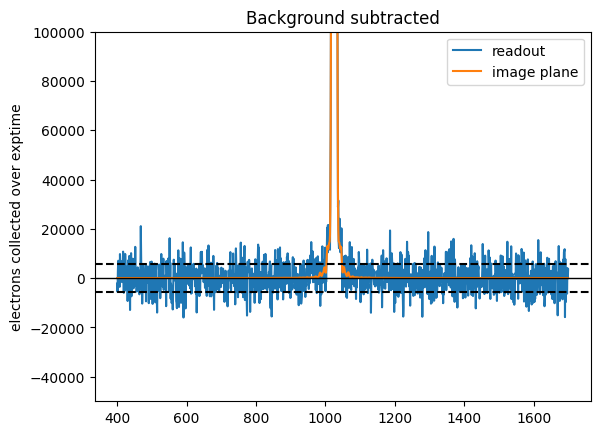

In [124]:
rms_bgsub = (bgsub[row, 400:800] * ndit * 2.5).std()

plt.plot(x, bgsub[row, 400:1700] * ndit * 2.5, label="readout")
plt.plot(x, bgsub_implane[row, 400:1700] * dit * ndit, label="image plane")
plt.axhline(-rms_bgsub, c='k', ls='--')
plt.axhline(rms_bgsub, c='k', ls='--')
plt.axhline(0, c='k', lw=1)
plt.ylabel("electrons collected over exptime")
plt.title("Background subtracted")
plt.legend()
plt.ylim(-5e4, 1e5)

My conclusion is that - provided the sky background is scaled transmitted correctly through scopesim - the SNR of the source in an observation of 3600 seconds is indeed a couple of 1000. This does seem high.